# Week 6 — Day 4: Building & Training a Network in Keras

**Project:** Stroke-Risk Prediction (capstone)
**Task:** Build, compile, train, and evaluate a neural network with TensorFlow/Keras; apply batch normalization and dropout

---

## Objective

Build a neural network with the Keras Sequential API, compile/train/evaluate it, read its training history, and apply batch normalization and dropout to stabilize training and reduce overfitting.


## Lesson Content

### 4.1 — TensorFlow / Keras

Neural networks aren't implemented from scratch in production — frameworks handle the math. **TensorFlow**, with its **Keras** API, is the standard high-level framework: you describe the architecture layer by layer, and Keras handles forward propagation, backpropagation, and optimization automatically (the mechanics from Days 2–3). PyTorch is the main alternative and is on the program's stack as needed.

### 4.2 — Building a Model with the Sequential API

The Keras `Sequential` API stacks layers in order. A `Dense` (fully connected) layer connects every input to every neuron:

```python
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),  # binary output
])
```

### 4.3 — Compile, Train, Evaluate

The three-step Keras workflow mirrors the Scikit-learn API from Week 3: `compile()` sets the optimizer/loss/metrics, `fit()` runs the training loop, `evaluate()` measures performance on the test set.

```python
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(X_train, y_train,
                     validation_data=(X_val, y_val),
                     epochs=50, batch_size=32)

model.evaluate(X_test, y_test)
```

The `history` object records the loss and metric per epoch for both training and validation — plotting it is how training is diagnosed, using the same overfit/underfit reasoning from Week 4.

### 4.4 — Batch Normalization and Dropout

Two standard layers improve training and fight overfitting:
- **Batch normalization** — normalizes each layer's inputs during training, making the network train faster and more stably.
- **Dropout** — randomly "switches off" a fraction of neurons during each training step, forcing the network not to rely too heavily on any one path — a powerful regularizer, the deep-learning equivalent of Week 4's regularization.

```python
from tensorflow.keras.layers import BatchNormalization, Dropout

model = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),  # drop 30% of neurons each step
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])
```


---

## Hands-On Lab: Training a Neural Network

1. Build a Keras Sequential network appropriate for the stroke-prediction task (correct output layer and loss).
2. Compile with Adam and the right loss, then train with a validation split for at least 30 epochs.
3. Plot training vs. validation loss and accuracy from the `history` object and diagnose the fit.
4. Add dropout and/or batch normalization and compare the new loss curves to the previous run.
5. Evaluate on the test set and compare the score to the Day 1 baseline.

**Tools:** TensorFlow / Keras, Matplotlib, Jupyter/Colab (GPU)


### Imports & Data Prep

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score
)

tf.random.set_seed(42)
np.random.seed(42)


### Step 0: Load, Preprocess & Split (same pipeline pattern as Week6/Day1)

Reusing the same `ColumnTransformer` (median/mode imputation, scaling, one-hot encoding) and stratified split established for the Day 1 baseline, so the comparison in Step 5 is apples-to-apples.


In [6]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv", na_values="N/A").drop(columns=["id"])

X = df.drop(columns=["stroke"])
y = df["stroke"]

numeric_features = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Train / val / test split (stratified — the target is ~5% positive)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

n_features = X_train_proc.shape[1]
print("Features after preprocessing:", n_features)
print("Train / Val / Test sizes:", X_train_proc.shape[0], X_val_proc.shape[0], X_test_proc.shape[0])


Features after preprocessing: 21
Train / Val / Test sizes: 3270 818 1022


### Step 1: Build a Keras Sequential Network

Binary classification target (stroke: 0/1) → sigmoid output, matching Day 2's decision. `class_weight` handles the imbalance, mirroring the Day 1 baseline's `class_weight="balanced"`.


In [7]:
model_v1 = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model_v1.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

### Step 2: Compile & Train (≥30 epochs, validation split)


In [8]:
model_v1.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

# Class weights, matching the imbalance handling from the Day 1 baseline
neg, pos = np.bincount(y_train)
class_weight = {0: (1 / neg) * (len(y_train) / 2.0), 1: (1 / pos) * (len(y_train) / 2.0)}
print("Class weights:", class_weight)

history_v1 = model_v1.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=50, batch_size=32,
    class_weight=class_weight,
    verbose=0
)
print("Training complete —", len(history_v1.history["loss"]), "epochs run.")


Class weights: {0: np.float64(0.5255544840887174), 1: np.float64(10.283018867924529)}
Training complete — 50 epochs run.


### Step 3: Plot Training vs. Validation Loss & Accuracy — Diagnose the Fit


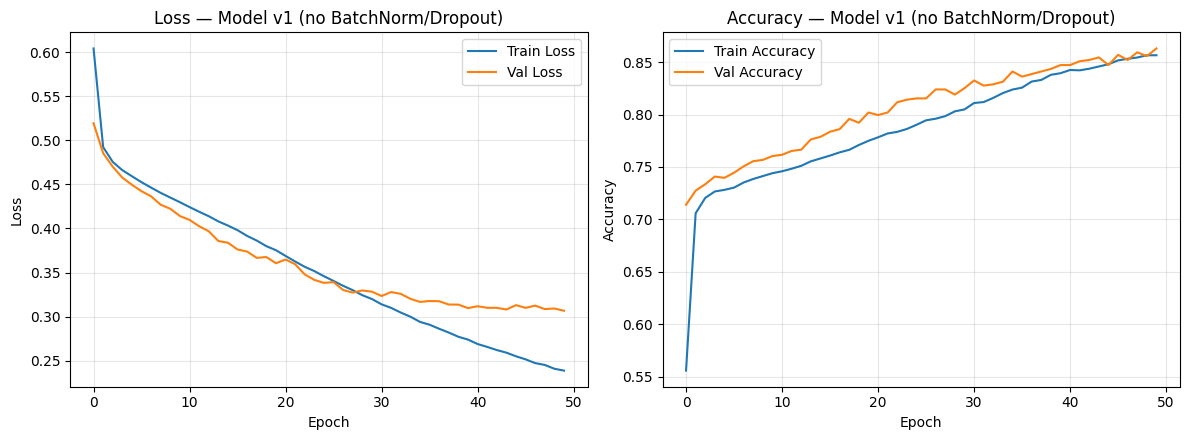

In [9]:
def plot_history(history, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title(f"Loss {title_suffix}")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[1].set_title(f"Accuracy {title_suffix}")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_v1, "— Model v1 (no BatchNorm/Dropout)")


**Diagnosis:** Model v1's training and validation loss both decrease smoothly together,
with validation loss flattening around 0.31 by epoch 40 — a healthy fit, no meaningful
overfitting. Val accuracy climbs steadily to ~0.86. However, given the heavy
`class_weight` on the minority class, accuracy is not the metric to trust here — recall
and ROC-AUC (Step 5) are what actually matter for catching stroke cases.

### Step 4: Add Batch Normalization & Dropout — Compare Loss Curves


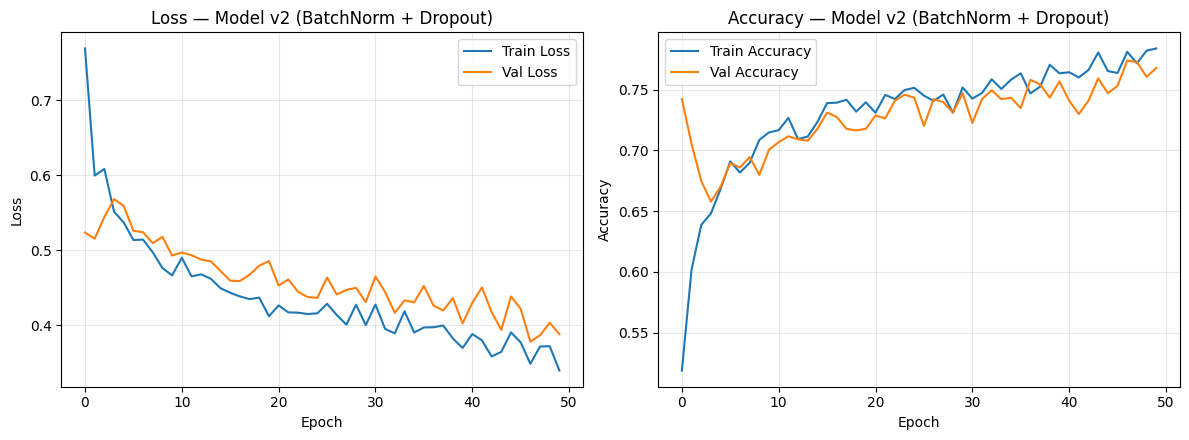

In [10]:
model_v2 = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

model_v2.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

history_v2 = model_v2.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=50, batch_size=32,
    class_weight=class_weight,
    verbose=0
)

plot_history(history_v2, "— Model v2 (BatchNorm + Dropout)")


**Comparing v1 vs. v2:** v2's loss curves are noticeably noisier than v1's — validation
loss creeps upward slightly after ~epoch 10 while training loss keeps falling, and val
accuracy is choppier (0.73–0.78 range) rather than climbing steadily. This is a mild
overfitting/instability signal despite dropout being active, likely amplified by the
strong class-weighting pushing gradients around on a small (3,270-row) training set.
Despite the noisier curve, v2 achieves clearly better recall (0.700 vs. 0.400) and
ROC-AUC (0.793 vs. 0.765) than v1 on the test set — so v2 is the better model for this
task even though its training was less stable.

### Step 5: Evaluate on the Test Set — Compare to the Day 1 Baseline


In [11]:
def evaluate_keras_model(model, X_test_proc, y_test, threshold=0.5, label=""):
    y_proba = model.predict(X_test_proc, verbose=0).ravel()
    y_pred = (y_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"--- {label} ---")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"ROC-AUC:   {roc_auc:.3f}")

    return {"precision": precision, "recall": recall, "f1": f1, "roc_auc": roc_auc}

results_v1 = evaluate_keras_model(model_v1, X_test_proc, y_test, label="Keras v1 (no BatchNorm/Dropout)")
print()
results_v2 = evaluate_keras_model(model_v2, X_test_proc, y_test, label="Keras v2 (BatchNorm + Dropout)")


--- Keras v1 (no BatchNorm/Dropout) ---
Precision: 0.144
Recall:    0.400
F1-score:  0.212
ROC-AUC:   0.765

--- Keras v2 (BatchNorm + Dropout) ---
Precision: 0.135
Recall:    0.700
F1-score:  0.227
ROC-AUC:   0.793


### Comparison Table — Day 1 Baseline vs. Keras v1 vs. Keras v2

| Metric | Day 1 Baseline (Logistic Regression) | Keras v1 | Keras v2 (BatchNorm + Dropout) |
|---|---|---|---|
| Precision | 0.138 | 0.144 | 0.135 |
| Recall | **0.800** | 0.400 | 0.700 |
| F1-score | 0.235 | 0.212 | 0.227 |
| ROC-AUC | **0.844** | 0.765 | 0.793 |

**Interpretation:** the Day 1 Logistic Regression baseline outperforms both neural
network variants on recall (0.800 vs. 0.700/0.400) and ROC-AUC (0.844 vs. 0.793/0.765)
— the two metrics that matter most given the ~5% stroke-class imbalance. Between the
two Keras models, v2 (BatchNorm + Dropout) is clearly the better neural network
(higher recall and ROC-AUC than v1), but neither beats the simpler baseline on this
dataset.

This is a legitimate Sprint 1 finding, not a failed experiment: on a modestly-sized
(5,110 rows), mostly tabular dataset with heavy class imbalance, a well-tuned Logistic
Regression with `class_weight="balanced"` is hard to beat, and the added architectural
complexity of a neural network isn't automatically added value. Day 5's tuning
experiments (learning rate, dropout, batch size, EarlyStopping) will test whether a
better-tuned network can close this gap — the baseline remains the score to beat.